In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


In [3]:
from typing_extensions import TypedDict
from typing import List

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

llm = ChatPerplexity(model="sonar-pro")

class MapReduceState(TypedDict):
    sections: List[str]
    partial_summaries: List[str]
    final_summary: str

In [4]:
def map_summarize(state: MapReduceState) -> MapReduceState:
    sections = state["sections"]
    partial_summaries = []

    for text in sections:
        prompt = f"Summarize this section in one or two sentences:\n\n{text}"
        response = llm.invoke([HumanMessage(content=prompt)])
        partial_summaries.append(response.content)

    return {
        "sections": sections,
        "partial_summaries": partial_summaries,
        "final_summary": state.get("final_summary", ""),
    }

def reduce_summaries(state: MapReduceState) -> MapReduceState:
    partial_summaries = state["partial_summaries"]
    joined = "\n".join(partial_summaries)

    prompt = (
        "You are given short summaries of different parts of the same topic.\n"
        "Combine them into one coherent, concise paragraph:\n\n"
        f"{joined}"
    )
    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "sections": state["sections"],
        "partial_summaries": partial_summaries,
        "final_summary": response.content,
    }

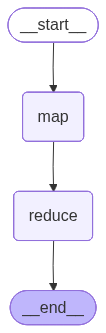

In [5]:
builder = StateGraph(MapReduceState)
builder.add_node("map", map_summarize)
builder.add_node("reduce", reduce_summaries)

builder.set_entry_point("map")
builder.add_edge("map", "reduce")
builder.add_edge("reduce", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
sections_1 = [
    "Time management is the practice of planning and organizing how to divide your time between specific activities. Good time management allows you to work smarter, not harder, so you can get more done in less time.",
    "Students often struggle with distractions like social media, notifications, and multitasking. Creating a dedicated study schedule and using techniques such as the Pomodoro method can help maintain focus.",
    "Prioritization is key: important and urgent tasks should be done first, while less important activities can be scheduled later or eliminated. Regularly reviewing your to-do list keeps you aligned with your goals."
]

initial_state_1 = {
    "sections": sections_1,
    "partial_summaries": [],
    "final_summary": "",
}

print("Running map-reduce summary for time management...\n")
result_1 = graph.invoke(initial_state_1)

print("Partial summaries:")
for i, s in enumerate(result_1["partial_summaries"], start=1):
    print(f"Section {i}:", s, "\n")

print("Final combined summary:")
print(result_1["final_summary"])

Running map-reduce summary for time management...



ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [7]:
from langchain_core.messages import HumanMessage

sections_3 = [
    "Cloud computing allows users to access computing resources like servers, storage, and databases over the internet.",
    "It offers scalability, meaning resources can be increased or decreased based on demand, which is useful for businesses with fluctuating workloads.",
    "Common cloud service models include IaaS, PaaS, and SaaS, each providing different levels of control and abstraction for the user."
]

initial_state_3 = {
    "sections": sections_3,
    "partial_summaries": [],
    "final_summary": "",
}

config_3 = {"configurable": {"thread_id": "map-reduce-demo-3"}}

print("Streaming map-reduce run for cloud computing topic...\n")
for event in graph.stream(initial_state_3, config=config_3, stream_mode="values"):
    partial = event.get("partial_summaries", [])
    final = event.get("final_summary", "")
    print("Current number of partial summaries:", len(partial))
    if final:
        print("\nCurrent final summary draft:")
        print(final)
    print("-" * 40)

Streaming map-reduce run for cloud computing topic...

Current number of partial summaries: 0
----------------------------------------
Current number of partial summaries: 3
----------------------------------------
Current number of partial summaries: 3

Current final summary draft:
Cloud computing delivers computing resources—including servers, storage, databases, and software—over the internet, allowing organizations to access and manage these services on-demand without the need for physical on-premises infrastructure[1][2][5]. This model enables businesses to pay only for what they use, reducing capital expenses and facilitating dynamic scaling of resources to efficiently handle fluctuating workloads[1][3][5]. The inherent scalability lets organizations optimize costs and maintain consistent performance by adjusting capacity in response to demand[1][4][5]. Cloud computing comprises three primary service models: **IaaS**, which offers maximum control over infrastructure; **PaaS**, wh